In [2]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [4]:
x = np.load("/kaggle/input/3-s-50-overlap/X_windows_3s_50_full_ds.npy")
y_disease = np.load("/kaggle/input/3-s-50-overlap/Y_disease_3s_50_labels.npy")
y_activity = np.load("/kaggle/input/3-s-50-overlap/Y_activity_3s_50_labels.npy")

In [5]:
print("X shape:", x.shape)  
print("Disease labels shape:", y_disease.shape)
print("Activity labels shape:", y_activity.shape)

X shape: (129444, 300, 12)
Disease labels shape: (129444,)
Activity labels shape: (129444,)


In [6]:
X_train, X_temp, y_disease_train, y_disease_temp, y_activity_train, y_activity_temp = train_test_split(x, y_disease, y_activity, test_size=0.2, random_state=42, stratify = y_disease)
print("X_train shape:", X_train.shape)
print("y_disease_train shape:", y_disease_train.shape)
print("y_activity_train shape:", y_activity_train.shape)

X_train shape: (103555, 300, 12)
y_disease_train shape: (103555,)
y_activity_train shape: (103555,)


In [7]:
X_val, X_test, y_disease_val, y_disease_test, y_activity_val, y_activity_test = train_test_split(
    X_temp, y_disease_temp, y_activity_temp,
    test_size=0.5, 
    random_state=42,
    stratify=y_disease_temp
)

print("Train shapes:", X_train.shape, y_disease_train.shape, y_activity_train.shape)
print("Val shapes:", X_val.shape, y_disease_val.shape, y_activity_val.shape)
print("Test shapes:", X_test.shape, y_disease_test.shape, y_activity_test.shape)

Train shapes: (103555, 300, 12) (103555,) (103555,)
Val shapes: (12944, 300, 12) (12944,) (12944,)
Test shapes: (12945, 300, 12) (12945,) (12945,)


In [8]:
import pandas as pd
(unique, counts) = np.unique(y_disease_train, return_counts=True)
print(pd.DataFrame({'class': unique, 'count': counts}))

   class  count
0      0  17443
1      1  60941
2      2  25171


In [9]:
from sklearn.preprocessing import StandardScaler
N, T, F = X_train.shape
scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, F)
X_val_2d   = X_val.reshape(-1, F)
X_test_2d  = X_test.reshape(-1, F)
scaler.fit(X_train_2d)
X_train_scaled = scaler.transform(X_train_2d).reshape(N, T, F)
X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val.shape[0], T, F)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape[0], T, F)


In [10]:
if y_disease_train.ndim > 1:
    y_disease_train = np.argmax(y_disease_train, axis=1)

if y_disease_val.ndim > 1:
    y_disease_val = np.argmax(y_disease_val, axis=1)

In [11]:
print("disease train shape:", y_disease_train.shape)
print("disease val shape:", y_disease_val.shape)
print("Unique labels in train:", np.unique(y_disease_train[:20]))

disease train shape: (103555,)
disease val shape: (12944,)
Unique labels in train: [0 1 2]


In [12]:
from sklearn.utils.class_weight import compute_class_weight
disease_classes = np.unique(y_disease_train)
disease_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=disease_classes,
    y=y_disease_train
)

# Convert to dictionary: {class_index: weight}
disease_class_weights = {i: w for i, w in zip(disease_classes, disease_weights_array)}
print("Disease class weights:", disease_class_weights)


Disease class weights: {0: 1.978921821552103, 1: 0.5664221678891606, 2: 1.371353276919206}


In [13]:
print("y_disease_train shape:", y_disease_train.shape)
print("sample_weights[0] shape:", np.array([disease_class_weights[c] for c in y_disease_train]).shape)

print("y_activity_train shape:", y_activity_train.shape)
print("sample_weights[1] shape:", np.ones(len(y_activity_train)).shape)


y_disease_train shape: (103555,)
sample_weights[0] shape: (103555,)
y_activity_train shape: (103555,)
sample_weights[1] shape: (103555,)


In [14]:
import tensorflow as tf
class attention_layer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):   
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W=self.add_weight(name="att_weight", shape=(input_shape[-1],input_shape[-1]), initializer="glorot_uniform", trainable=True)
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],), initializer="zeros", trainable=True)
        self.v=self.add_weight(name="att_v", shape=(input_shape[-1],1), initializer="glorot_uniform", trainable=True)        
        super().build(input_shape)
    def call(self, inputs, mask=None):
        u = tf.tanh(tf.matmul(inputs,self.W)+self.b)
        scores = tf.matmul(u,self.v)
        alpha = tf.nn.softmax(scores, axis=1)
        context_vector = tf.reduce_sum(inputs*alpha, axis=1)
        return context_vector

In [15]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, LSTM, Dropout, Attention, Permute, Multiply, Lambda, Concatenate, GlobalAveragePooling1D, BatchNormalization

In [16]:
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback

# Custom callback to compute F1 after each epoch
class F1ScoreCallback(Callback):
    def __init__(self, val_data, batch_size=32):
        super().__init__()
        self.validation_data = val_data
        self.batch_size = batch_size
        self.val_f1s = []

    def on_epoch_end(self, epoch, logs=None):
        X_val, y_val_dict = self.validation_data
        y_true = y_val_dict["disease_output"]

        # Get predictions
        y_pred = self.model.predict(X_val, batch_size=self.batch_size, verbose=0)
        y_pred_classes = np.argmax(y_pred[0], axis=1)  # [0] -> disease_output

        # Compute macro F1
        f1 = f1_score(y_true, y_pred_classes, average="macro")
        self.val_f1s.append(f1)

        print(f"\nEpoch {epoch+1}: val_macro_f1 = {f1:.4f}")
        logs["val_macro_f1"] = f1


In [21]:
f1_callback = F1ScoreCallback(
    val_data=(X_val_scaled, {"disease_output": y_disease_val, "activity_output": y_activity_val}),
    batch_size=256)

In [22]:

def build_multi_task_model(timesteps=100, features=12, num_disease=3, num_activities=10, conv_filter=64, lstm_units=64, dropout_rate=0.3):
    input_layer = tf.keras.layers.Input(shape=(timesteps, features), name="inputs")

    #CNN
    x=layers.Conv1D(conv_filter, kernel_size=7, activation='relu',kernel_regularizer=l2(0.001), padding="valid")(input_layer)
    x=layers.BatchNormalization()(x)
    x=layers.Dropout(dropout_rate)(x)
    x=layers.Conv1D(conv_filter, kernel_size=5, activation='relu',kernel_regularizer=l2(0.001), padding="valid")(x)
    x=layers.BatchNormalization()(x)
    x=layers.MaxPooling1D(pool_size=2)(x)
    x=layers.Dropout(dropout_rate)(x)

    #BiLSTM
    x=layers.LSTM(lstm_units,kernel_regularizer=l2(0.001), return_sequences=True)(x)
    x=Dropout(0.3)(x)

    #Attention
    atten_out=attention_layer()(x)
    x=Dense(64, activation='relu', kernel_regularizer=l2(0.001))(atten_out)
    x=Dropout(0.3)(x)

    #Disease output
    disease_output = Dense(num_disease, activation='softmax', name='disease_output')(x)

    #Activity output
    activity_output = Dense(num_activities, activation='softmax', name='activity_output')(x)

    model=Model(inputs=input_layer, outputs=[disease_output, activity_output])
    return model

In [23]:
import tensorflow as tf
from tensorflow.keras import backend as K

class MacroF1(tf.keras.metrics.Metric):
    def __init__(self, name="macro_f1", **kwargs):
        super(MacroF1, self).__init__(name=name, **kwargs)
        self.f1 = self.add_weight(name="f1", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.argmax(y_pred, axis=1)

        # Compute F1 using py_function
        f1 = tf.py_function(self._compute_f1, (y_true, y_pred), tf.float32)
        f1.set_shape([])  # <-- FIX: tell TF this is a scalar

        self.f1.assign_add(f1)
        self.count.assign_add(1.0)

    def result(self):
        return self.f1 / self.count

    def reset_states(self):
        self.f1.assign(0.0)
        self.count.assign(0.0)

    def _compute_f1(self, y_true, y_pred):
        from sklearn.metrics import f1_score
        f1 = f1_score(y_true.numpy(), y_pred.numpy(), average="macro")
        return tf.constant(f1, dtype=tf.float32)  # <-- FIX

In [24]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_disease = len(np.unique(y_disease_train))
num_activities = len(np.unique(y_activity_train))

model = build_multi_task_model(timesteps=input_shape[0], features=input_shape[1], num_disease=num_disease, num_activities=num_activities)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'disease_output': 'sparse_categorical_crossentropy',
        'activity_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        "disease_output": ["accuracy", MacroF1(name="macro_f1")],
        'activity_output': 'accuracy'
    }
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_path = "/content/checkpoints/epoch_{epoch:02d}_val_loss_{val_loss:.4f}.h5"

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,   # save full model (set True if only weights needed)
    save_freq="epoch",         # save at every epoch
    monitor="val_loss",        # metric to monitor
    save_best_only=False,      # False → save all epochs
    verbose=1
)

In [25]:
history = model.fit(
    X_train_scaled,
    [y_disease_train, y_activity_train],   # <-- list, not dict
    validation_data = (
        X_val_scaled,
        [y_disease_val, y_activity_val]    # <-- also list
    ),
    epochs=100,
    batch_size=256,
    sample_weight=[
        np.array([disease_class_weights[c] for c in y_disease_train]),  # weights for disease_output
        np.ones(len(y_activity_train))                                  # weights for activity_output
    ],
    callbacks=[checkpoint_callback, f1_callback]
)

Epoch 1/100


I0000 00:00:1756214364.969950     111 cuda_dnn.cc:529] Loaded cuDNN version 90300


405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - activity_output_accuracy: 0.6710 - activity_output_loss: 1.1135 - disease_output_accuracy: 0.3477 - disease_output_loss: 1.0994 - disease_output_macro_f1: 0.3321 - loss: 2.4314
Epoch 1: saving model to /content/checkpoints/epoch_01_val_loss_2.5027.h5

Epoch 1: val_macro_f1 = 0.3978
405/405 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - activity_output_accuracy: 0.6712 - activity_output_loss: 1.1127 - disease_output_accuracy: 0.3477 - disease_output_loss: 1.0993 - disease_output_macro_f1: 0.3321 - loss: 2.4305 - val_activity_output_accuracy: 0.5659 - val_activity_output_loss: 1.3138 - val_disease_output_accuracy: 0.4188 - val_disease_output_loss: 1.0224 - val_disease_output_macro_f1: 0.3962 - val_loss: 2.5027 - val_macro_f1: 0.3978
Epoch 2/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - activity_output_accuracy: 0.8444 - activity_output_loss: 0.4793 - disease_output_accuracy: 0.3834 - disease_output_loss: 1.0151 - disease_output_macro_f1: 0.3780 - loss:

In [26]:
import os

# Save directory inside Kaggle working
save_dir = "/kaggle/working/csv-5s/50_overlap"
os.makedirs(save_dir, exist_ok=True)

# Model path (use .keras extension for Keras 3.x)
model_path = os.path.join(save_dir, "1cnn_lstm_1dense_5s_50pct_100epoch_128.keras")

# Save model
model.save(model_path)

print(f"✅ Model saved at: {model_path}")

✅ Model saved at: /kaggle/working/csv-5s/50_overlap/1cnn_lstm_1dense_5s_50pct_100epoch_128.keras


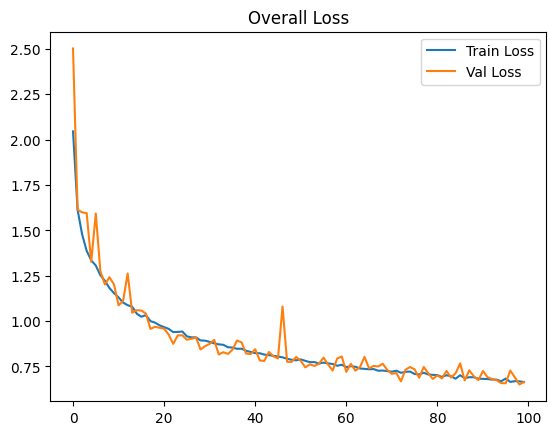

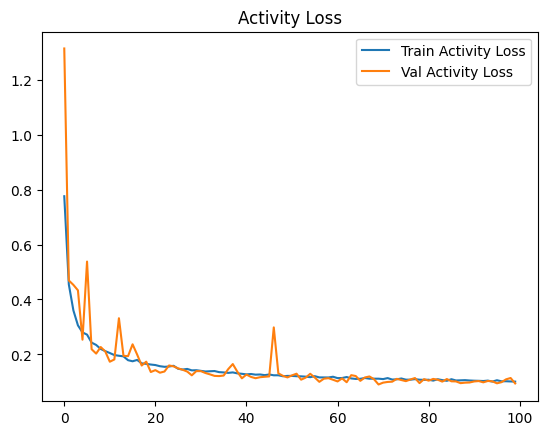

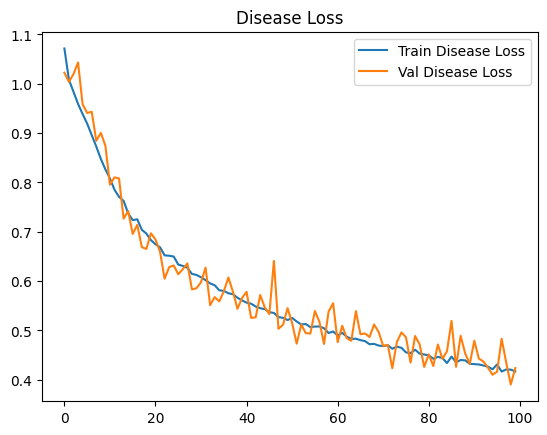

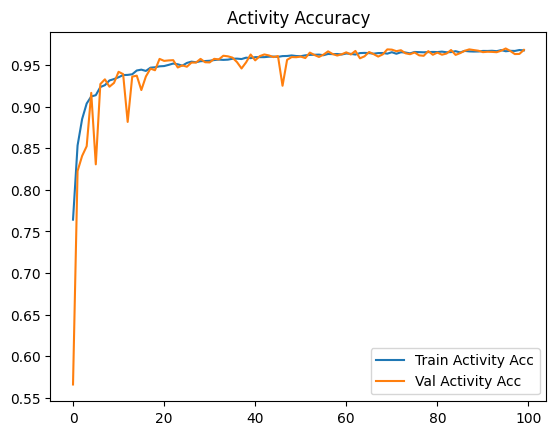

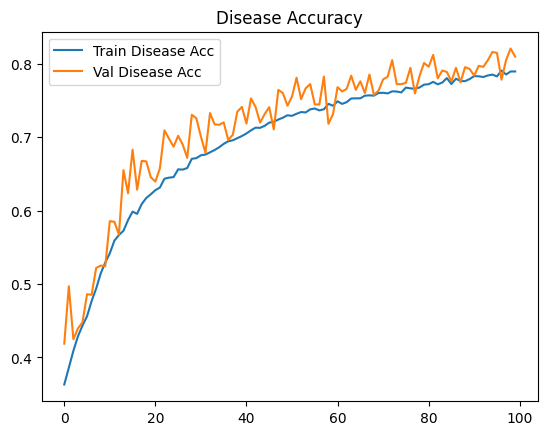

In [27]:
import matplotlib.pyplot as plt

# ---- Plot overall loss ----
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Overall Loss")
plt.show()

# ---- Plot activity loss ----
plt.plot(history.history["activity_output_loss"], label="Train Activity Loss")
plt.plot(history.history["val_activity_output_loss"], label="Val Activity Loss")
plt.legend()
plt.title("Activity Loss")
plt.show()

# ---- Plot disease loss ----
plt.plot(history.history["disease_output_loss"], label="Train Disease Loss")
plt.plot(history.history["val_disease_output_loss"], label="Val Disease Loss")
plt.legend()
plt.title("Disease Loss")
plt.show()

# ---- Plot activity accuracy ----
plt.plot(history.history["activity_output_accuracy"], label="Train Activity Acc")
plt.plot(history.history["val_activity_output_accuracy"], label="Val Activity Acc")
plt.legend()
plt.title("Activity Accuracy")
plt.show()

plt.plot(history.history["disease_output_accuracy"], label="Train Disease Acc")
plt.plot(history.history["val_disease_output_accuracy"], label="Val Disease Acc")
plt.legend()
plt.title("Disease Accuracy")
plt.show()



405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Disease Classification Report:
              precision    recall  f1-score   support

   Disease_0     0.6218    0.9170    0.7411      2180
   Disease_1     0.9207    0.7745    0.8413      7618
   Disease_2     0.7691    0.8119    0.7899      3147

    accuracy                         0.8076     12945
   macro avg     0.7705    0.8344    0.7908     12945
weighted avg     0.8335    0.8076    0.8119     12945



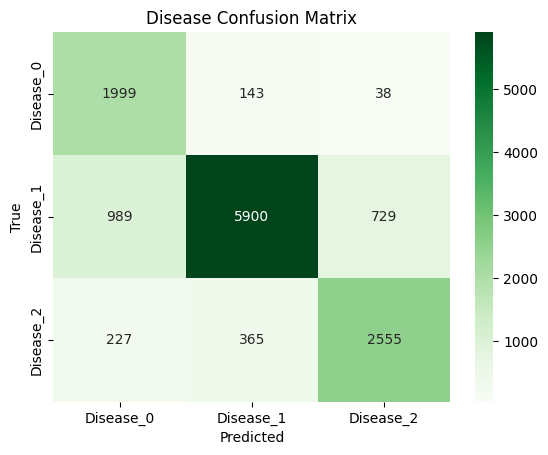


Activity Classification Report:
              precision    recall  f1-score   support

  Activity_0     0.8384    0.8966    0.8665       706
  Activity_1     0.9603    0.9700    0.9651       699
  Activity_2     0.9946    0.9984    0.9965      3661
  Activity_3     0.9628    0.9918    0.9771       730
  Activity_4     0.9043    0.8513    0.8770       733
  Activity_5     0.9872    0.9830    0.9851       707
  Activity_6     0.9944    0.9983    0.9964      3576
  Activity_7     0.8987    0.8871    0.8929       700
  Activity_8     0.9683    0.9031    0.9345       743
  Activity_9     0.9869    0.9855    0.9862       690

    accuracy                         0.9696     12945
   macro avg     0.9496    0.9465    0.9477     12945
weighted avg     0.9698    0.9696    0.9695     12945



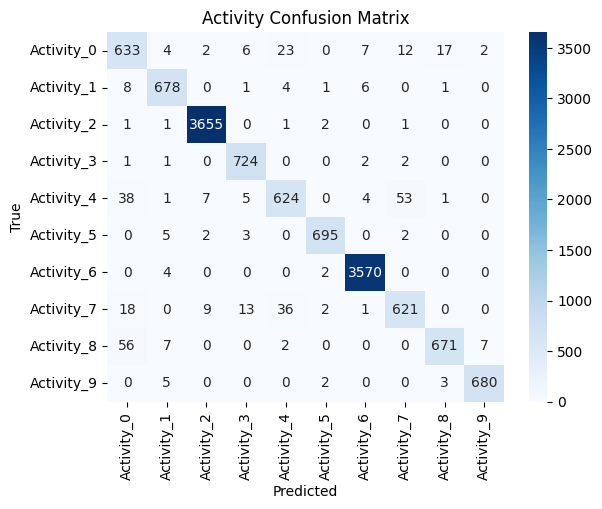

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---- Predictions ----
y_pred_test = model.predict(X_test_scaled)

y_pred_disease = np.argmax(y_pred_test[0], axis=1)
y_pred_activity = np.argmax(y_pred_test[1], axis=1)

# ---- Disease Report ----
print("\nDisease Classification Report:")
print(classification_report(y_disease_test, y_pred_disease, target_names=[f"Disease_{i}" for i in range(3)], digits=4))

cm_disease = confusion_matrix(y_disease_test, y_pred_disease)
sns.heatmap(cm_disease, annot=True, fmt="d", cmap="Greens",
            xticklabels=[f"Disease_{i}" for i in range(3)],
            yticklabels=[f"Disease_{i}" for i in range(3)])
plt.title("Disease Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---- Activity Report ----
print("\nActivity Classification Report:")
print(classification_report(y_activity_test, y_pred_activity, target_names=[f"Activity_{i}" for i in range(10)], digits=4))

cm_activity = confusion_matrix(y_activity_test, y_pred_activity)
sns.heatmap(cm_activity, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"Activity_{i}" for i in range(10)],
            yticklabels=[f"Activity_{i}" for i in range(10)])
plt.title("Activity Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
